# Part2 Modeling

In [1]:
import os
os.chdir('./proj1_data/')
os.getcwd()

'/home/tako/Kasetsart/statistics/project1/proj1_data'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import statsmodels.api as sm

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## Data

In [4]:
Dataset = "part2_cleaned.csv"
orig_df = pd.read_csv(Dataset)
orig_df

,Country Name,Year,Agricultural land (% of land area),"Agriculture, forestry, and fishing, value added (% of GDP)",Arable land (% of land area),Cereal yield (kg per hectare),Crop production index (2014-2016 = 100),Fertilizer consumption (kilograms per hectare of arable land),Food production index (2014-2016 = 100),Forest area (% of land area),...,High-technology exports (% of manufactured exports),High-technology exports (current US$),Medium and high-tech exports (% manufactured exports),Merchandise exports (current US$),Merchandise imports (current US$),Merchandise trade (% of GDP),"Contributing family workers, female (% of female employment) (modeled ILO estimate)","Contributing family workers, male (% of male employment) (modeled ILO estimate)",Region,ThirdWorld
0,Afghanistan,2017,58.12,26.42,11.80,2091.4,99.210,20.45,99.84,1.85,...,6.23,86113314.5,2.120000,7.230000e+08,7.065000e+09,41.53,62.58,12.20,South Asia,Yes
1,Albania,2017,42.86,19.02,22.34,4813.0,105.840,99.81,103.88,28.79,...,0.09,1118611.0,3.560000,2.292000e+09,5.271000e+09,58.09,29.97,17.04,Eastern Europe,No
2,Algeria,2017,17.36,11.03,3.14,990.3,104.400,20.84,102.87,0.82,...,0.96,9028313.0,3.950000,3.519100e+10,4.605900e+10,42.79,2.33,1.70,Africa,No
3,American Samoa,2017,13.90,6.59,4.65,3052.7,103.615,41.67,104.00,86.10,...,6.23,86113314.5,33.202833,3.970000e+08,5.950000e+08,162.09,4.25,1.99,Australia and Oceanea,No
4,Andorra,2017,40.04,0.56,1.74,3052.7,103.615,90.00,104.00,34.04,...,23.25,24238350.0,33.202833,1.180000e+08,1.478000e+09,53.20,4.25,1.99,Western Europe,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1075,Virgin Islands (U.S.),2021,9.43,6.59,2.57,3052.7,103.615,90.00,104.00,57.31,...,6.23,86113314.5,33.202833,6.608000e+09,9.121000e+09,53.03,0.34,0.21,North America,No
1076,West Bank and Gaza,2021,64.93,6.32,6.95,2251.9,117.310,371.97,117.39,1.68,...,1.60,14531924.0,15.110000,6.608000e+09,9.121000e+09,53.03,8.55,3.44,Middle East,No
1077,"Yemen, Rep.",2021,44.42,6.59,2.19,1524.8,124.710,10.63,120.77,1.04,...,6.23,86113314.5,0.250000,6.620000e+08,5.054000e+09,29.68,37.64,9.04,Middle East,Yes
1078,Zambia,2021,32.07,3.00,5.11,2525.0,136.310,63.90,127.49,60.03,...,0.95,10218867.0,28.800000,1.010100e+10,6.435000e+09,74.84,4.87,2.36,Africa,Yes


In [5]:
orig_df.shape

(1080, 83)

## Functions

In [6]:
# Scale by standardized normal distribution, (x-mean)/sd
def scale_standard(X_train, X_test):
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled

# Scale by min-max, (x-min)/(max-min)
def scale_minmax(X_train, X_test):
    from sklearn.preprocessing import MinMaxScaler
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled

# Scale by robust, (x-median)/iqr
def scale_robust(X_train, X_test):
    from sklearn.preprocessing import RobustScaler
    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled

In [7]:
def transform_log(X, skew_var):
    temp_X = X.copy()
    temp_X[skew_var] = np.log1p(temp_X[skew_var])   # log1p = log(1 + y)
    return temp_X
    
def transform_boxcox(X, skew_var):
    temp_X = X.copy()
    from scipy.stats import boxcox
    temp_bc, lambda_bc = boxcox(temp_X[skew_var])
    temp_X[skew_var] = temp_bc
    return temp_X

def transform_yeojohnson(X, skew_var):
    temp_X = X.copy()
    from sklearn.preprocessing import PowerTransformer
    pt = PowerTransformer(method='yeo-johnson')
    temp_X[skew_var] = pt.fit_transform(temp_X[[skew_var]])
    return temp_X

In [8]:
def remove_outliers_iqr(df, outlier_vars):
    temp_df = df.copy()
    for _var in outlier_vars:
        q1 = temp_df[_var].quantile(0.25)
        q3 = temp_df[_var].quantile(0.75)
        iqr = q3-q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        mask = (temp_df[_var] < lower_bound) | (temp_df[_var] > upper_bound)
        temp_df = temp_df[~mask]
        print(temp_df.shape)
    col_names = df.columns.tolist()
    new_df = pd.DataFrame(temp_df, col_names)
    return temp_df

In [9]:
# One-Hot Encoder version 1: convert all categorical variables
def onehot_encoder_all(df):
    from sklearn.preprocessing import OneHotEncoder
    onehot_encoder = OneHotEncoder(sparse_output=False,        # use sparse=True for large data
                                    handle_unknown='ignore')
    oh_encoded = onehot_encoder.fit_transform(df)
    ohe_df = pd.DataFrame(oh_encoded,
                         columns=onehot_encoder.get_feature_names_out(df.columns))
    return ohe_df

# One-Hot Encoder version 2: Convert selected variables
def onehot_encoder_selected(df, encoded_vars):
    df = pd.get_dummies(df, columns=encoded_vars, drop_first=False)
    return df

# Label Encoder
def label_encoder(df, encoded_var):
    from sklearn.preprocessing import LabelEncoder
    label_encoder = LabelEncoder()
    df[encoded_var] = label_encoder.fit_transform(df[encoded_var])
    return df

# Ordinal Encoder
def ordinal_encoder(df, encoded_var, encode_order):
    from sklearn.preprocessing import OrdinalEncoder
    ordinal_encoder = OrdinalEncoder(categories=[encode_order])
    df[encoded_var] = ordinal_encoder.fit_transform(df[[encoded_var]])
    return df

# Frequenct Encoder
def frequent_encoder(df, encoded_var):
    freq_encoding = df[encoded_var].value_counts() 
    df[encoded_var] = df[encoded_var].map(freq_encoding)
    return df

# Target Encoder
def target_encoder(df, encoded_var, encoded_num):
    import category_encoders as ce
    target_encoder = ce.TargetEncoder(cols=[encoded_var])
    df[encoded_var] = target_encoder.fit_transform(df[encoded_var], df[encoded_num])
    return df

# Binary Encoder
def binary_encoder(df, encoded_var):
    import category_encoders as ce
    binary_encoder = ce.BinaryEncoder(cols=[encoded_var])
    df_binary = binary_encoder.fit_transform(df[encoded_var])
    df_binary.columns = [f"{encoded_var}_bin_{i}" for i in range(df_binary.shape[1])]
    df = pd.concat([df, df_binary], axis=1)
    df = df.drop([encoded_var], axis=1)
    return df 

### Hash Encoder
def hash_encoder(df, encoded_var, hash_len):
    import category_encoders as ce
    hash_encoder = ce.HashingEncoder(cols=[encoded_var], n_components=hash_len)  # n_components = length of hash, default = 8
    df_hash = hash_encoder.fit_transform(df[encoded_var])
    df_hash.columns = [f"{encoded_var}_hash_{i}" for i in range(df_hash.shape[1])]
    df = pd.concat([df, df_hash], axis=1)
    df = df.drop([encoded_var], axis=1)
    return df 

In [10]:
def compute_regression_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

def compute_mape(y_true, y_pred):
    # Mean Absolute Percentage Error
    # Note: MAPE fails if y_true contains zeros.
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def compute_smape(y_true, y_pred):
    # Symmetric Mean Absolute Percentage Error
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))

def compute_rmsle(y_true, y_pred, neg_mask=0):
    # Root Mean Squared Log Error
    # RMSLE is good for right-skewed data
    # Note: log1p(x) = log(1+x), and the log parameter must be positive. 
    # Therefore, x >= -1. Otherwise, log1p(1+x) encounters an invalid value.
        
    if neg_mask == 1:
        mask = (y_true >= 0) & (y_pred >= 0)
        y_true = y_true[mask]
        y_pred = y_pred[mask]
    
    np_y_true, np_y_pred = np.array(y_true), np.array(y_pred)
    rmsle = np.sqrt(np.mean((np.log1p(np_y_true) - np.log1p(np_y_pred))**2))  # Root Mean Squared Log Error

    return rmsle

In [11]:
# Residuals vs Fitted Plot
def create_residuals_fitted_plot(y_true, y_pred):
    residuals = y_true - y_pred
    
    plt.figure(figsize=(7, 5))
    plt.scatter(y_pred, residuals)
    plt.axhline(y=0, color='red', linestyle='--')
    plt.xlabel("Fitted Values (Predicted)")
    plt.ylabel("Residuals")
    plt.title("Residuals vs Fitted Plot")
    plt.show()

# Residual qqplot
def create_residuals_qqplot(y_true, y_pred):
    residuals = y_true - y_pred
    sm.qqplot(residuals, line='45', fit=True)
    plt.title("Q-Q Plot - Statsmodels")
    plt.show()

In [12]:
def check_extreme_values(X_true, y_true, y_pred):
    residuals = y_true - y_pred
    
    X_computed = np.hstack([np.ones((X_true.shape[0], 1)), X_true])  # Add intercept column
    n, p = X_true.shape
    
    mse = np.sum(residuals**2) / (n - p)
    
    XtX_inv = np.linalg.inv(X_computed.T @ X_computed)  # @ = matrix multiplication operator.
    hat_matrix = X_computed @ XtX_inv @ X_computed.T 
    
    # Leverage = Outliers in X-direction = Extreme predictor values
    leverage = np.diag(hat_matrix)     
    leverage_threshold = 2 * p / n  # if leverage > 2p/n or 3p/n, leverage is considered high
    print("Leverage thresold:", leverage_threshold)
    
    # Leverage = Outliers in Y-direction = Extreme response values
    standardized_residuals = residuals / np.sqrt(mse * (1 - leverage))
    print("Standardized residuals thresold:", 2)
    
    cooks_distance = (standardized_residuals**2 / p) * (leverage / (1 - leverage))
    cooks_threshold = 4 / n
    print("Cooks thresold:", cooks_threshold)    
    cooks_df = cooks_distance[cooks_distance > cooks_threshold]
    index_to_remove = cooks_df.index.tolist()
    
    return leverage, leverage_threshold, standardized_residuals, cooks_distance, cooks_threshold, index_to_remove

In [13]:
def create_cooks_plot(X_true, cooks_distance, cooks_threshold):
    n, p = X_true.shape
    plt.figure(figsize=(10, 5))
    plt.bar(np.arange(n), cooks_distance, color='skyblue', edgecolor='k')
    plt.xlabel("Observation Index")
    plt.ylabel("Cook's Distance")
    plt.title("Cook's Distance Bar Plot")
    
    # Threshold line for influential points
    plt.axhline(y=cooks_threshold, color='red', linestyle='--', label=f"Threshold = {cooks_threshold:.4f}")
    plt.legend()
    plt.show()

In [14]:
def get_permutation_importance(model, X, X_test, y_test):
    from sklearn.inspection import permutation_importance
    result = permutation_importance(model, X_test, y_test, n_repeats=10)
    
    perm_df = pd.DataFrame({
        "feature": X.columns,
        "importance_mean": result.importances_mean,
        "importance_std": result.importances_std
    }).sort_values("importance_mean", ascending=False)
    
    return perm_df

    # Higher value = more important feature, relatively compared to other features
    # Near-zero value = unimportant feature, relatively compared to other features
    # Negative value = noisy feature

In [15]:
def create_shap_values_plot(model, X, X_train, X_test):
    import shap
    X_train_df = pd.DataFrame(X_train, columns=X.columns.tolist())
    X_test_df = pd.DataFrame(X_test, columns=X.columns.tolist())
    if len(X_train) > 200:
        explainer = shap.KernelExplainer(model.predict, X_train_df.sample(200))
    else: 
        explainer = shap.KernelExplainer(model.predict, X_train_df)
    if len(X_test) > 100:
        shap_values = explainer.shap_values(X_test_df.sample(100))
        shap.summary_plot(shap_values, X_test_df.sample(100))
    else:
        shap_values = explainer.shap_values(X_test_df)
        shap.summary_plot(shap_values, X_test_df)

In [16]:
def ols_model(X_true, y_true):
    import statsmodels.api as sm
    X_true_sm = sm.add_constant(X_true)

    # Fit OLS model
    ols_model = sm.OLS(y_true, X_true_sm).fit()

    # Summary table
    print(ols_model.summary())

## Workflows

### Workflow 1

In [17]:
df = orig_df.drop(['Country Name'], axis=1)

categorical = df.select_dtypes(include=['object']).columns
print(categorical)
for col in categorical:
    print(col, ":", len(df[col].unique()), df[col].isnull().sum())

df['ThirdWorld'] = df['ThirdWorld'].map({'Yes': 1, 'No': 0})
df = pd.get_dummies(df, columns=['Region'], drop_first=True)

df = df.astype(float)

print(df.shape)
df.head()

Index(['Region', 'ThirdWorld'], dtype='object')
Region : 13 0
ThirdWorld : 2 0
(1080, 93)


,Year,Agricultural land (% of land area),"Agriculture, forestry, and fishing, value added (% of GDP)",Arable land (% of land area),Cereal yield (kg per hectare),Crop production index (2014-2016 = 100),Fertilizer consumption (kilograms per hectare of arable land),Food production index (2014-2016 = 100),Forest area (% of land area),Forest area (sq. km),...,Region_Eastern Europe,Region_Middle East,Region_North America,Region_Northern Europe,Region_South America,Region_South Asia,Region_Southeast Asia,Region_Thailand,Region_Western Asia,Region_Western Europe
0,2017.0,58.12,26.42,11.80,2091.4,99.210,20.45,99.84,1.85,12084.40,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,2017.0,42.86,19.02,22.34,4813.0,105.840,99.81,103.88,28.79,7889.03,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2017.0,17.36,11.03,3.14,990.3,104.400,20.84,102.87,0.82,19430.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2017.0,13.90,6.59,4.65,3052.7,103.615,41.67,104.00,86.10,172.20,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2017.0,40.04,0.56,1.74,3052.7,103.615,90.00,104.00,34.04,160.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [18]:
goal = "GNI per capita, PPP (current international $)"
y = orig_df[goal]
y

0        2360.0
1       12800.0
2       13520.0
3       14380.0
4       14380.0
         ...   
1075    14380.0
1076     6800.0
1077    14380.0
1078     3220.0
1079     3220.0
Name: GNI per capita, PPP (current international $), Length: 1080, dtype: float64

In [19]:
X = df.drop([goal], axis=1)
X.head()

,Year,Agricultural land (% of land area),"Agriculture, forestry, and fishing, value added (% of GDP)",Arable land (% of land area),Cereal yield (kg per hectare),Crop production index (2014-2016 = 100),Fertilizer consumption (kilograms per hectare of arable land),Food production index (2014-2016 = 100),Forest area (% of land area),Forest area (sq. km),...,Region_Eastern Europe,Region_Middle East,Region_North America,Region_Northern Europe,Region_South America,Region_South Asia,Region_Southeast Asia,Region_Thailand,Region_Western Asia,Region_Western Europe
0,2017.0,58.12,26.42,11.80,2091.4,99.210,20.45,99.84,1.85,12084.40,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,2017.0,42.86,19.02,22.34,4813.0,105.840,99.81,103.88,28.79,7889.03,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2017.0,17.36,11.03,3.14,990.3,104.400,20.84,102.87,0.82,19430.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2017.0,13.90,6.59,4.65,3052.7,103.615,41.67,104.00,86.10,172.20,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2017.0,40.04,0.56,1.74,3052.7,103.615,90.00,104.00,34.04,160.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [20]:
X1_train, X1_test, y1_train, y1_test = train_test_split(X, y, test_size=0.2, random_state=42)

feature_names = X1_train.columns
X1_train, X1_test = scale_standard(X1_train, X1_test)

model = LinearRegression()
model.fit(X1_train, y1_train)

# Use model for predicted responses
y1_train_pred = model.predict(X1_train)
y1_pred = model.predict(X1_test)

# Measure performances
rmse, mae, r2 = compute_regression_metrics(y1_test, y1_pred)
mape = compute_mape(y1_test, y1_pred)
print("RMSE: ", rmse)
print("MAE: ", mae)
print("MAPE: ", mape)
print("R2: ", r2)

RMSE:  7762.990791757296
MAE:  5420.087154233529
MAPE:  64.0835024629669
R2:  0.8610200729358167


In [21]:
coeff_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': model.coef_
})

coeff_df['Abs_Coefficient'] = coeff_df['Coefficient'].abs()
coeff_df_sorted = coeff_df.sort_values(by='Abs_Coefficient', ascending=False)

print(coeff_df_sorted)

                                              Feature   Coefficient  \
23           Urban population (% of total population)  1.807140e+06   
14           Rural population (% of total population)  1.804352e+06   
39       Population ages 0-14 (% of total population)  8.035657e+05   
40      Population ages 15-64 (% of total population)  5.126025e+05   
62  Population ages 65 and above (% of total popul...  5.005013e+05   
..                                                ...           ...   
50     Secure Internet servers (per 1 million people)  1.062734e+02   
81                                   Region_East Asia  6.387323e+01   
36  Government expenditure on education, total (% ...  2.710444e+01   
61                                      Net migration -2.682461e+01   
63         Population, female (% of total population)  1.974401e+01   

    Abs_Coefficient  
23     1.807140e+06  
14     1.804352e+06  
39     8.035657e+05  
40     5.126025e+05  
62     5.005013e+05  
..             

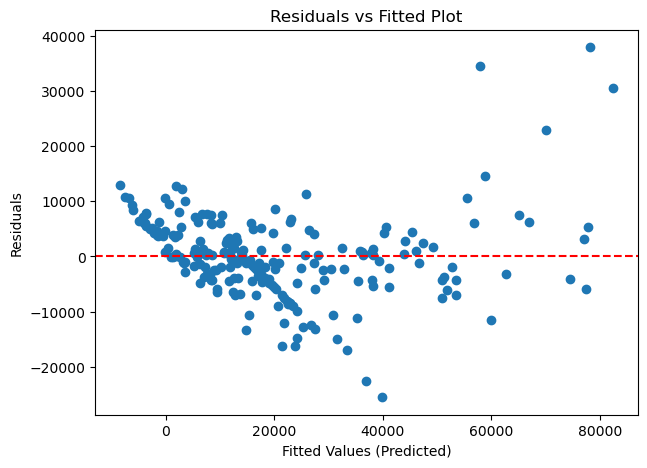

In [22]:
create_residuals_fitted_plot(y1_test, y1_pred)

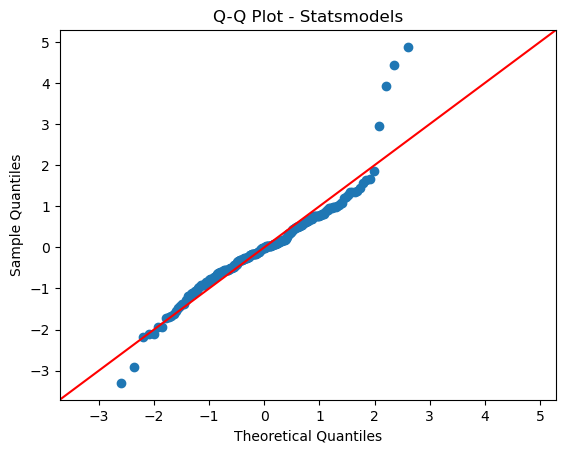

In [23]:
create_residuals_qqplot(y1_test, y1_pred)

Leverage thresold: 0.21296296296296297
Standardized residuals thresold: 2
Cooks thresold: 0.004629629629629629
0.053703703703703705


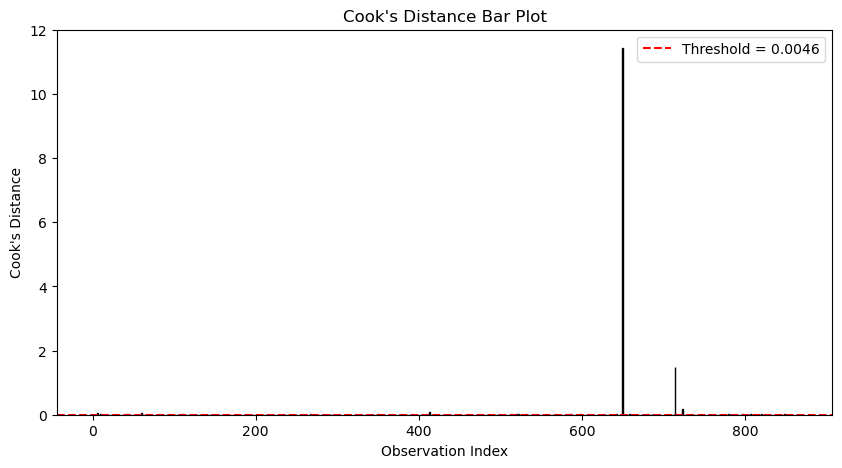

In [24]:
leverage, leverage_threshold, standardized_residuals, cooks_distance, cooks_threshold, index_to_remove = check_extreme_values(X1_train, y1_train, y1_train_pred)
main_index_to_remove = index_to_remove
print(len(main_index_to_remove)/df.shape[0])
create_cooks_plot(X1_train, cooks_distance, cooks_threshold)

### Workflow 2

In [25]:
existing_indices = [i for i in main_index_to_remove if i in X.index]
X2 = X.drop(existing_indices, axis=0)
y2 = y.loc[X2.index]
print(X2.shape, y2.shape)

# Train/Test Split
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

X2_train, X2_test = scale_standard(X2_train, X2_test)

# Construct a model
selected_alpha = 1.0
from sklearn.linear_model import Ridge 
model = Ridge(alpha=selected_alpha)  
model.fit(X2_train, y2_train)

# Use model for predicted responses
y2_train_pred = model.predict(X2_train)
y2_pred = model.predict(X2_test)

# Measure performances
rmse, mae, r2 = compute_regression_metrics(y2_test, y2_pred)
mape = compute_mape(y2_test, y2_pred)
print("RMSE: ", rmse)
print("MAE: ", mae)
print("MAPE: ", mape)
print("R2: ", r2)

(1022, 92) (1022,)
RMSE:  6119.783570126637
MAE:  4425.606815309482
MAPE:  51.25226085716431
R2:  0.9146394529392209


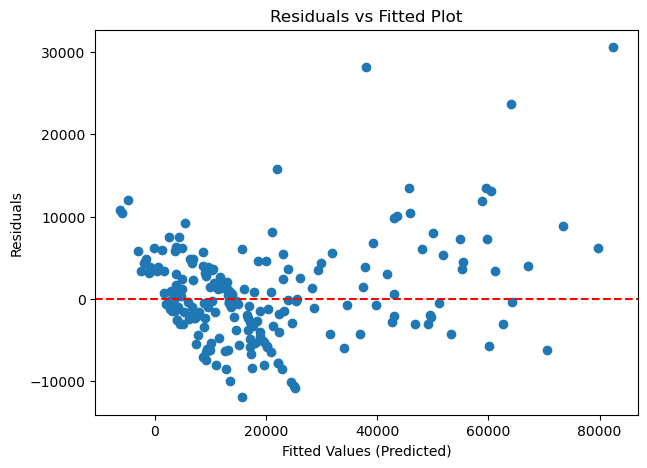

In [26]:
create_residuals_fitted_plot(y2_test, y2_pred)

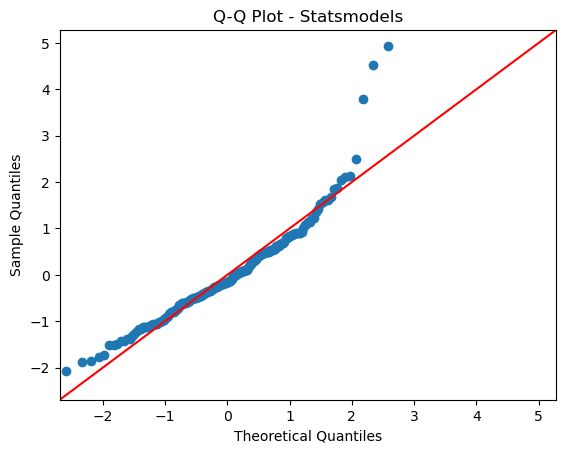

In [27]:
create_residuals_qqplot(y2_test, y2_pred)

Leverage thresold: 0.2252141982864137
Standardized residuals thresold: 2
Cooks thresold: 0.004895960832313341
0.10092592592592593


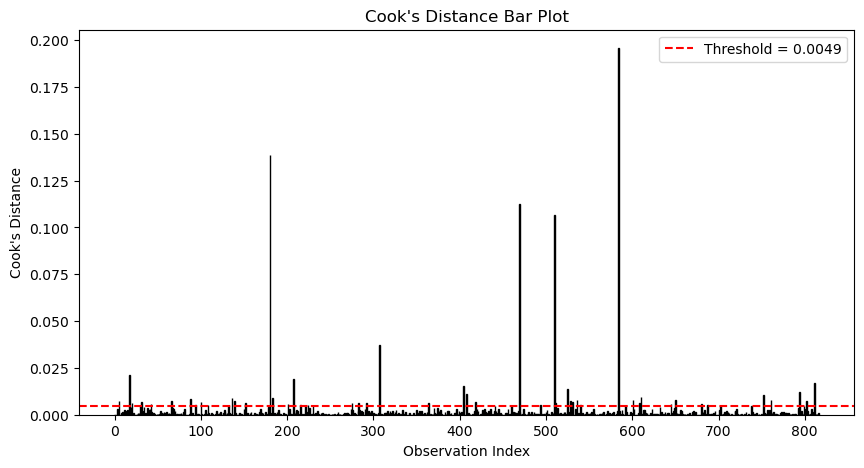

In [28]:
leverage, leverage_threshold, standardized_residuals, cooks_distance, cooks_threshold, index_to_remove = check_extreme_values(X2_train, y2_train, y2_train_pred)
past_main_index_to_remove = main_index_to_remove
main_index_to_remove = main_index_to_remove + index_to_remove
print(len(main_index_to_remove)/df.shape[0])
create_cooks_plot(X2_train, cooks_distance, cooks_threshold)

### Workflow 3

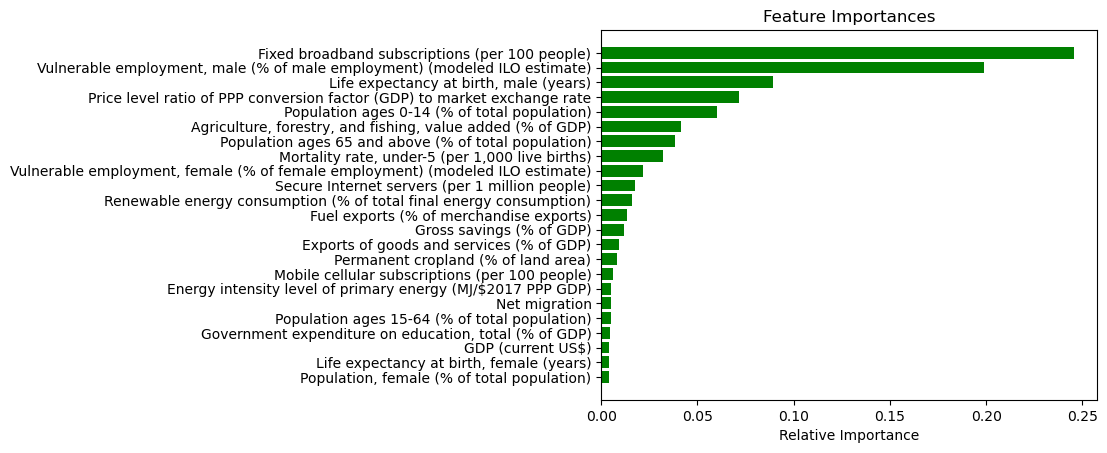

In [29]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(max_depth=10,n_estimators=100,random_state=69)
model.fit(X2,y2)

n_features = 23      # can be adjusted

# Plot feature importance
features = X2.columns
importances = model.feature_importances_
indices = np.argsort(importances)[-n_features:]  # sort top n features
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='g', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

In [30]:
important_features = [features[i] for i in indices]
updated_vars = []
for i in range(-1,-n_features-1,-1):
    updated_vars.append(important_features[i])

number_of_features = n_features

updated_vars = updated_vars[0: number_of_features]
print(len(updated_vars))
updated_vars

23


['Fixed broadband subscriptions (per 100 people)',
 'Vulnerable employment, male (% of male employment) (modeled ILO estimate)',
 'Life expectancy at birth, male (years)',
 'Price level ratio of PPP conversion factor (GDP) to market exchange rate',
 'Population ages 0-14 (% of total population)',
 'Agriculture, forestry, and fishing, value added (% of GDP)',
 'Population ages 65 and above (% of total population)',
 'Mortality rate, under-5 (per 1,000 live births)',
 'Vulnerable employment, female (% of female employment) (modeled ILO estimate)',
 'Secure Internet servers (per 1 million people)',
 'Renewable energy consumption (% of total final energy consumption)',
 'Fuel exports (% of merchandise exports)',
 'Gross savings (% of GDP)',
 'Exports of goods and services (% of GDP)',
 'Permanent cropland (% of land area)',
 'Mobile cellular subscriptions (per 100 people)',
 'Energy intensity level of primary energy (MJ/$2017 PPP GDP)',
 'Net migration',
 'Population ages 15-64 (% of total

In [31]:
X3 = X2[updated_vars]

base_X3_train, base_X3_test, y3_train, y3_test = train_test_split(X3, y2, test_size=0.2, random_state=42)

# to find weights in mlp system, data values are important
# thus, to obtain mlp model, scaling is needed.
X3_train, X3_test = scale_standard(base_X3_train, base_X3_test)

selected_layers = (100,50)         # Default = (100,)
selected_activate = 'relu'       # Default = 'relu', Options: {‘identity’, ‘logistic’, ‘tanh’, ‘relu’}
selected_max_iter = 10000        # Default = 200

from sklearn.neural_network import MLPRegressor
# For more info, go to: https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPRegressor.html
#model = MLPRegressor()
model = MLPRegressor(hidden_layer_sizes=selected_layers, activation=selected_activate, max_iter=selected_max_iter, random_state=1)
model.fit(X3_train, y3_train)
######################################

# Use model for predicted responses
y3_train_pred = model.predict(X3_train)
y3_pred = model.predict(X3_test)

# Measure performances
rmse, mae, r2 = compute_regression_metrics(y3_test, y3_pred)
mape = compute_mape(y3_test, y3_pred)
print("RMSE: ", rmse)
print("MAE: ", mae)
print("MAPE: ", mape)
print("R2: ", r2)

RMSE:  3821.1120459566964
MAE:  2485.5849186585842
MAPE:  25.253304208510297
R2:  0.9667214336606647


## Result interpretation

Using 200 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/100 [00:00<?, ?it/s]

/nix/store/8fk44f44pb38da87ifkkmdm9c2i977vh-devenv-profile/lib/python3.13/site-packages/shap/plots/_beeswarm.py:1150: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


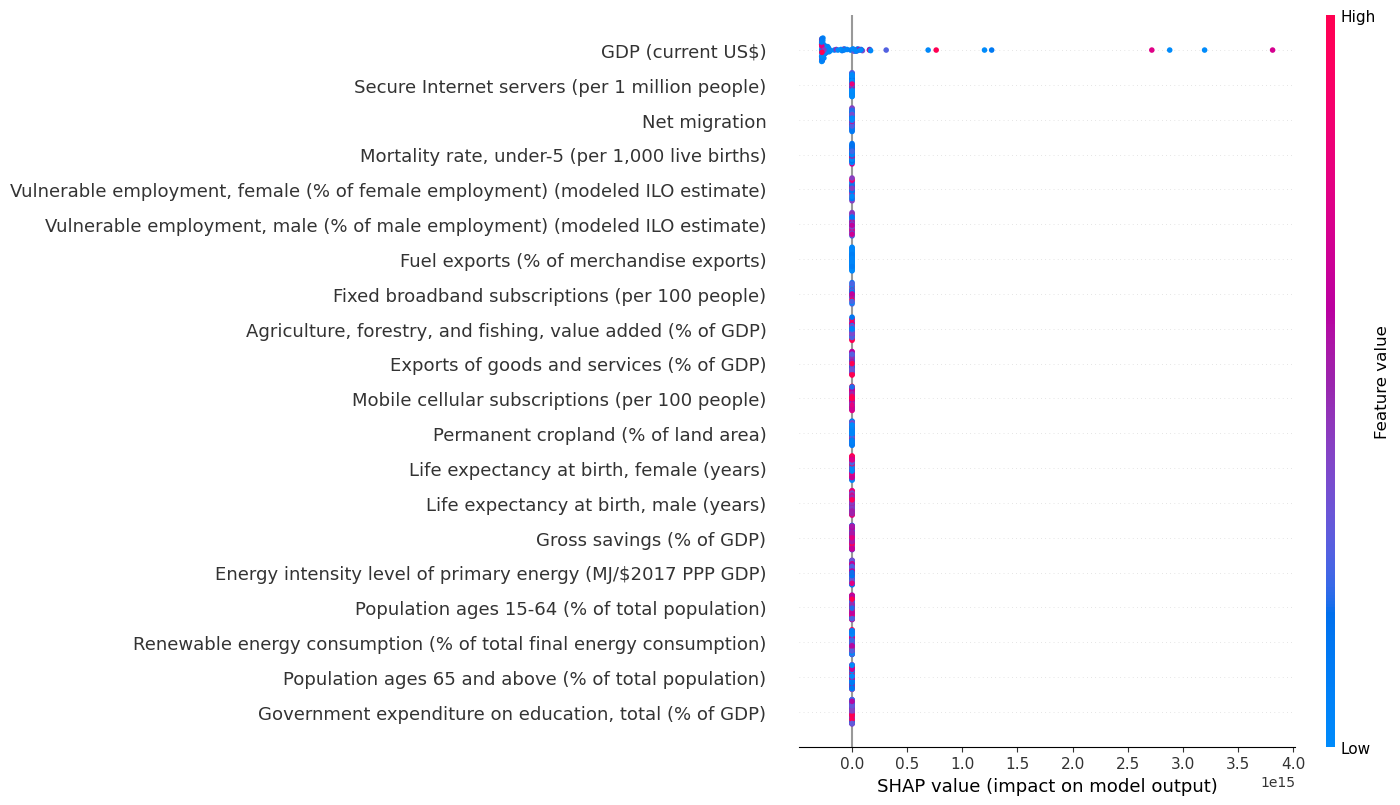

In [32]:
create_shap_values_plot(model, X3, base_X3_train, base_X3_test)

In [33]:
get_permutation_importance(model, X3, X3_test, y3_test)

,feature,importance_mean,importance_std
3,Price level ratio of PPP conversion factor (GD...,0.087400,0.010923
21,"Life expectancy at birth, female (years)",0.081962,0.006661
12,Gross savings (% of GDP),0.069996,0.005307
13,Exports of goods and services (% of GDP),0.066281,0.007077
7,"Mortality rate, under-5 (per 1,000 live births)",0.066081,0.006398
1,"Vulnerable employment, male (% of male employm...",0.045800,0.007843
10,Renewable energy consumption (% of total final...,0.041798,0.008232
2,"Life expectancy at birth, male (years)",0.039664,0.007606
18,Population ages 15-64 (% of total population),0.033660,0.005298
8,"Vulnerable employment, female (% of female emp...",0.033170,0.007516
